## 1. Data Loading & Cleaning

In [1]:
from src.preprocess import full_pipeline
import pandas as pd
DATA_PATH = 'data/GlobalWeatherRepository.csv'
df = full_pipeline(DATA_PATH)
print(f'\nFinal shape: {df.shape}')
df.head(3)

Loaded 144,627 rows x 41 columns

Missing values (0 columns affected):
Series([], )

After imputation: 0 total nulls remain

Outlier counts (before handling):
  temperature_celsius: 2,381
  wind_mph: 2,257
  humidity: 0
  pressure_mb: 4,183
  precip_mm: 29,242

Engineered features. Shape: (144627, 52)

Preprocessing complete. Final shape: (144627, 52)

Final shape: (144627, 52)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,year,month,day,hour,dayofyear,week,season,discomfort_index,heat_index_approx,pressure_category
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,2024,5,16,13,137,20,Spring,1.992,25.96740,Normal
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,2024,5,16,10,137,20,Spring,6.486,16.53931,Normal
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,2024,5,16,9,137,20,Spring,2.726,24.68078,Normal


In [2]:
# Data types & missing value summary
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_pct': (df.isnull().mean()*100).round(2),
    'unique': df.nunique()
})
summary.sort_values('null_pct', ascending=False).head(20)

,dtype,non_null,null_pct,unique
country,object,144627,0.0,211
location_name,object,144627,0.0,257
latitude,float64,144627,0.0,397
longitude,float64,144627,0.0,403
timezone,object,144627,0.0,199
last_updated_epoch,int64,144627,0.0,1319
last_updated,datetime64[ns],144627,0.0,23868
temperature_celsius,float64,144627,0.0,488
temperature_fahrenheit,float64,144627,0.0,1179
condition_text,object,144627,0.0,49


In [3]:
# Numeric summary for key weather variables
key_cols = ['temperature_celsius','feelslike_celsius','humidity',
            'wind_mph','pressure_mb','precip_mm','vis_km','uv_index']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(2)

,temperature_celsius,humidity,wind_mph,pressure_mb,precip_mm,uv_index
count,144627.00,144627.00,144627.00,144627.00,144627.00,144627.00
mean,21.35,66.79,7.91,1014.04,0.01,3.25
std,9.32,23.76,4.98,6.54,0.02,3.53
min,-2.60,2.00,2.20,998.00,0.00,0.00
25%,15.70,51.00,3.80,1010.00,0.00,0.10
50%,23.70,72.00,6.70,1013.00,0.00,1.80
75%,27.90,86.00,11.00,1018.00,0.02,6.00
max,46.20,100.00,21.80,1030.00,0.05,16.30


## 2. Exploratory Data Analysis (EDA)

  Saved: outputs/figures/01_temperature_analysis.png


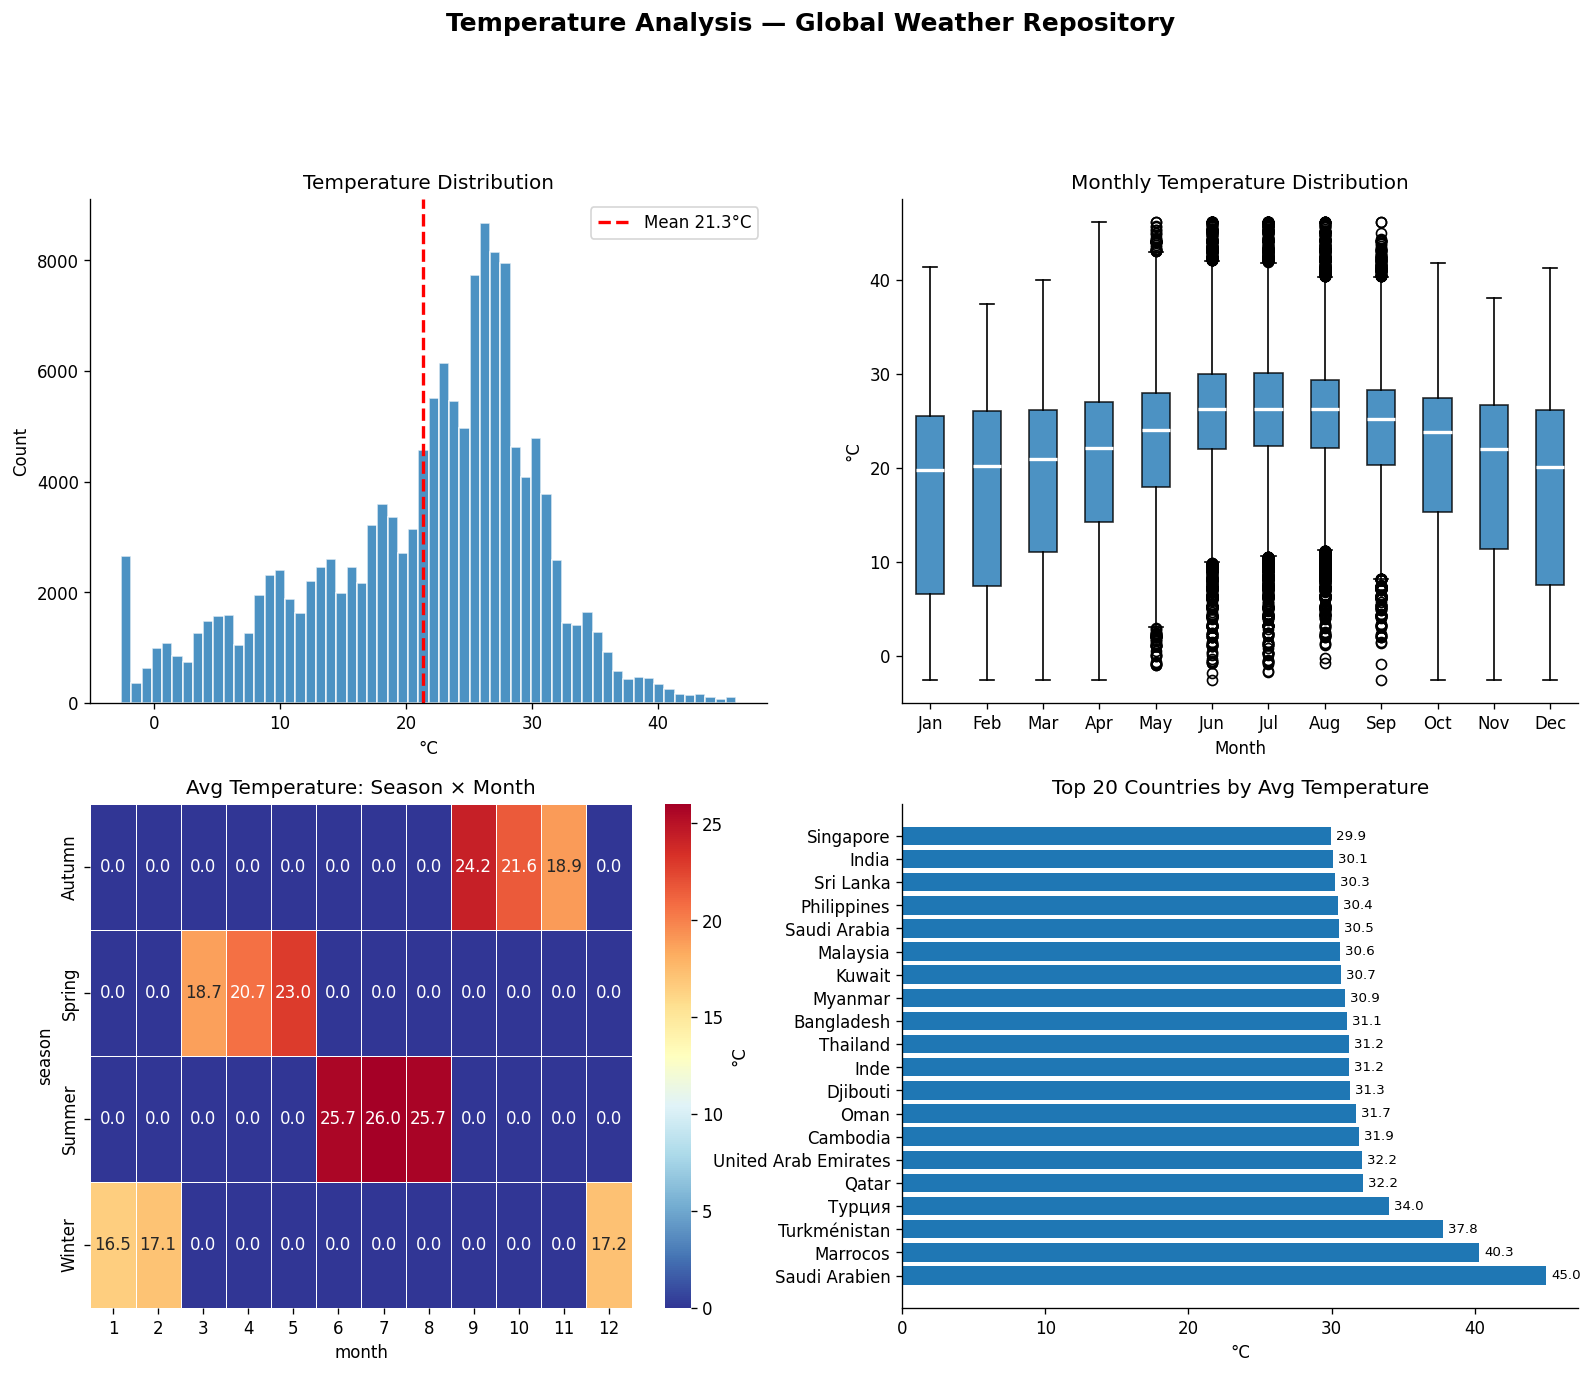

In [5]:
from src.explorer import plot_temperature
path = plot_temperature(df)
from IPython.display import Image
Image(path)

  Saved: outputs/figures/02_precipitation_analysis.png


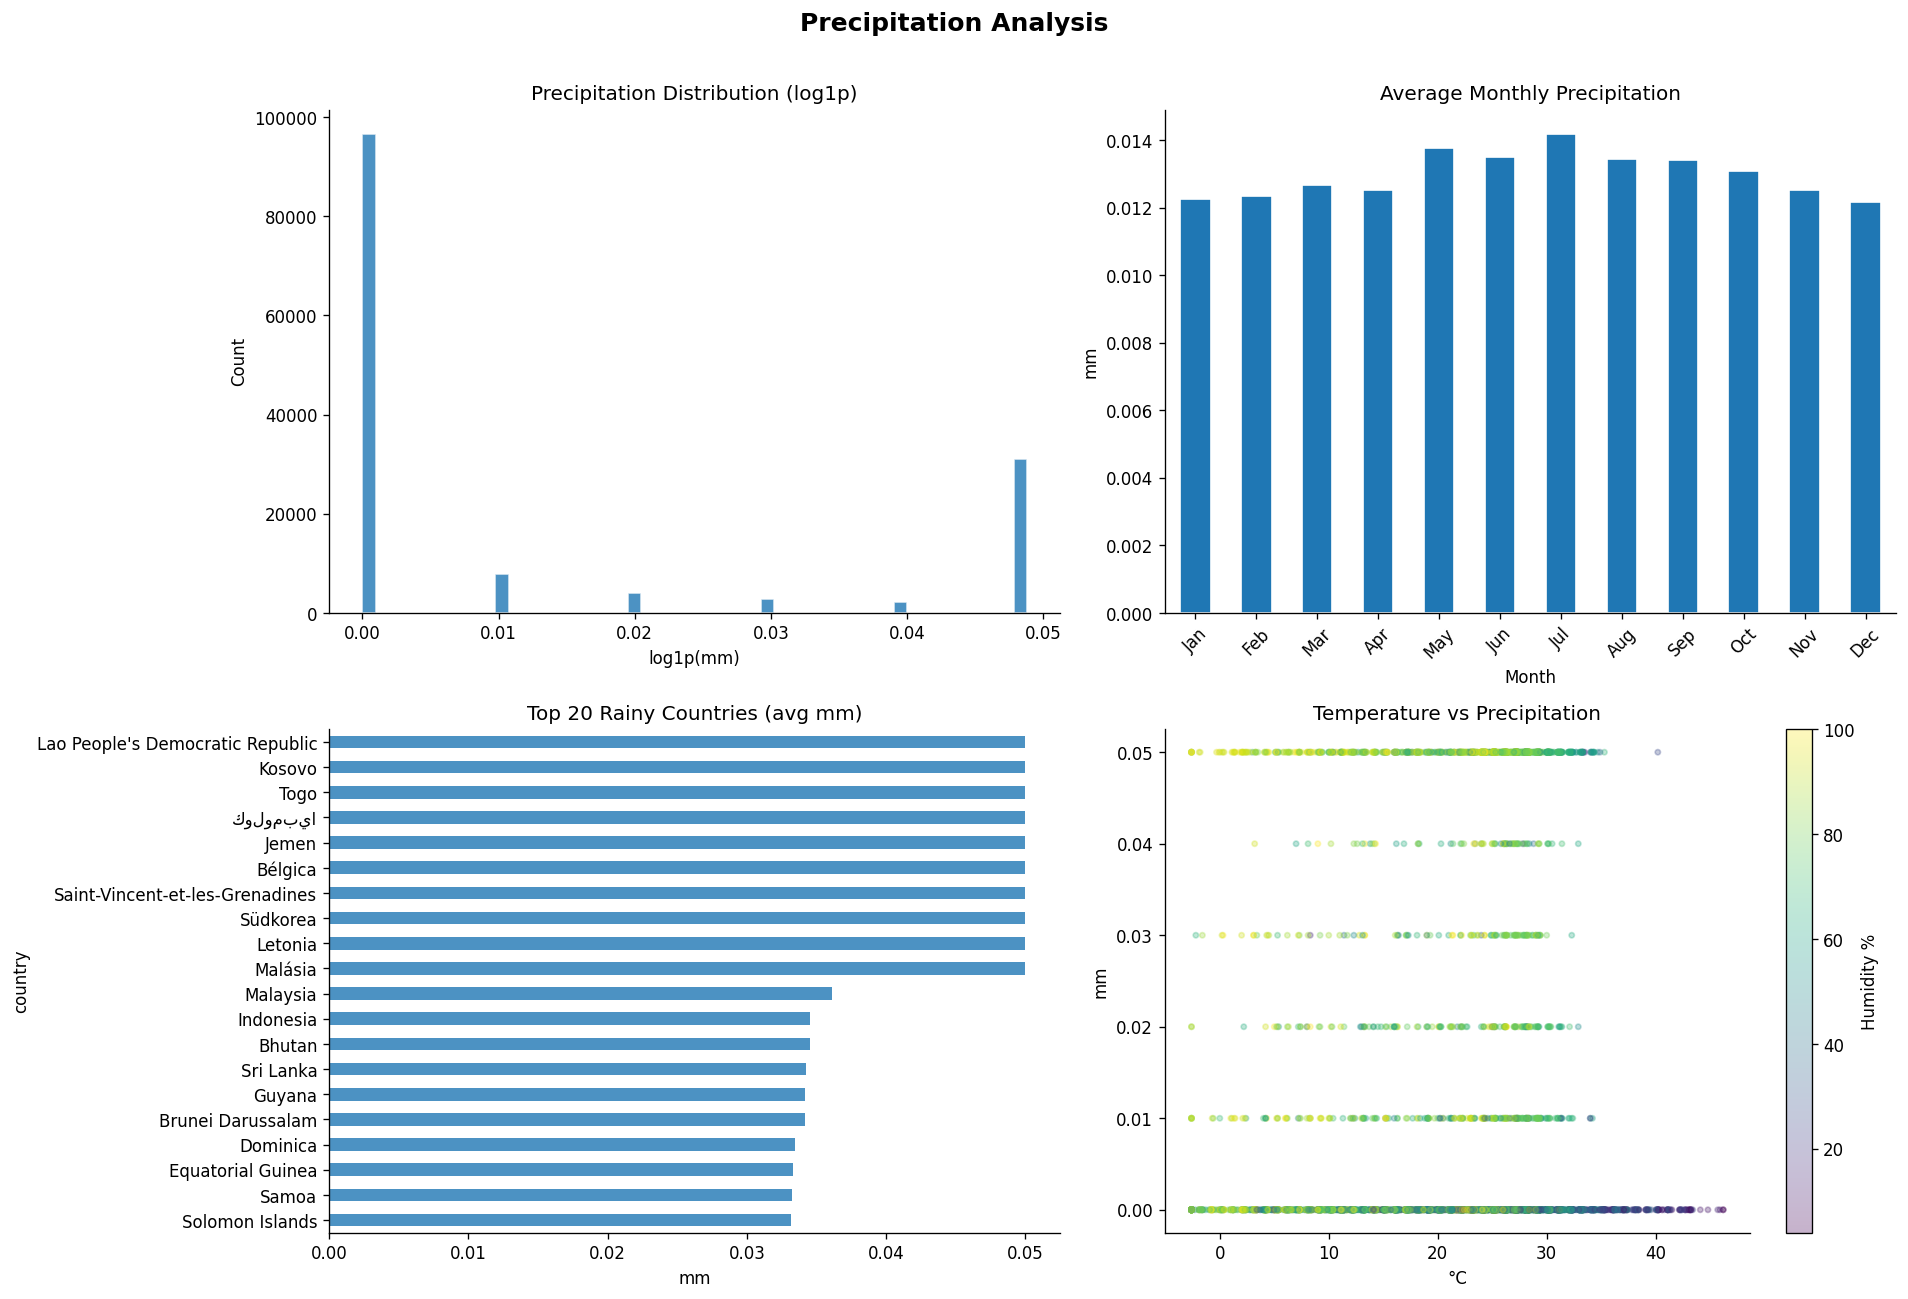

In [6]:
from src.explorer import plot_precipitation
Image(plot_precipitation(df))

  Saved: outputs/figures/03_correlation_heatmap.png


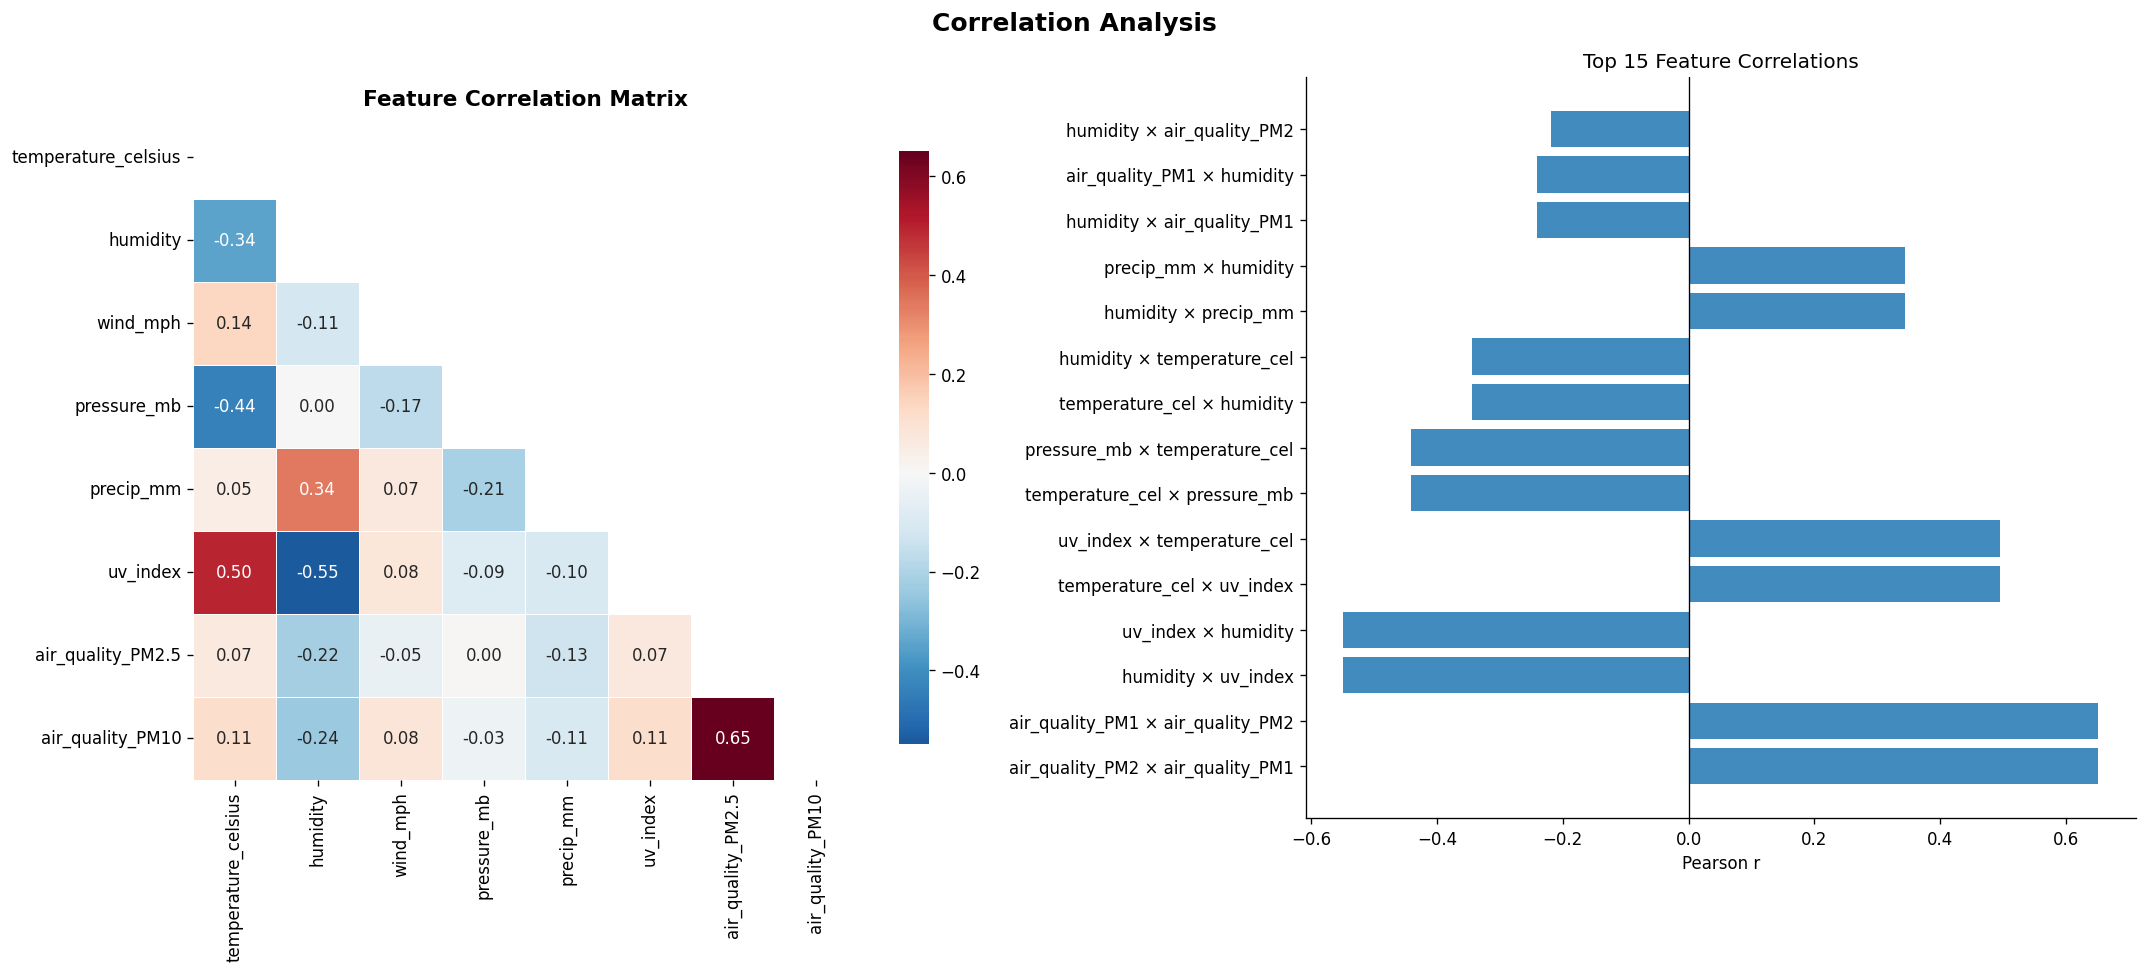

In [7]:
from src.explorer import plot_correlation
Image(plot_correlation(df))

  Saved: outputs/figures/04_time_trends.png


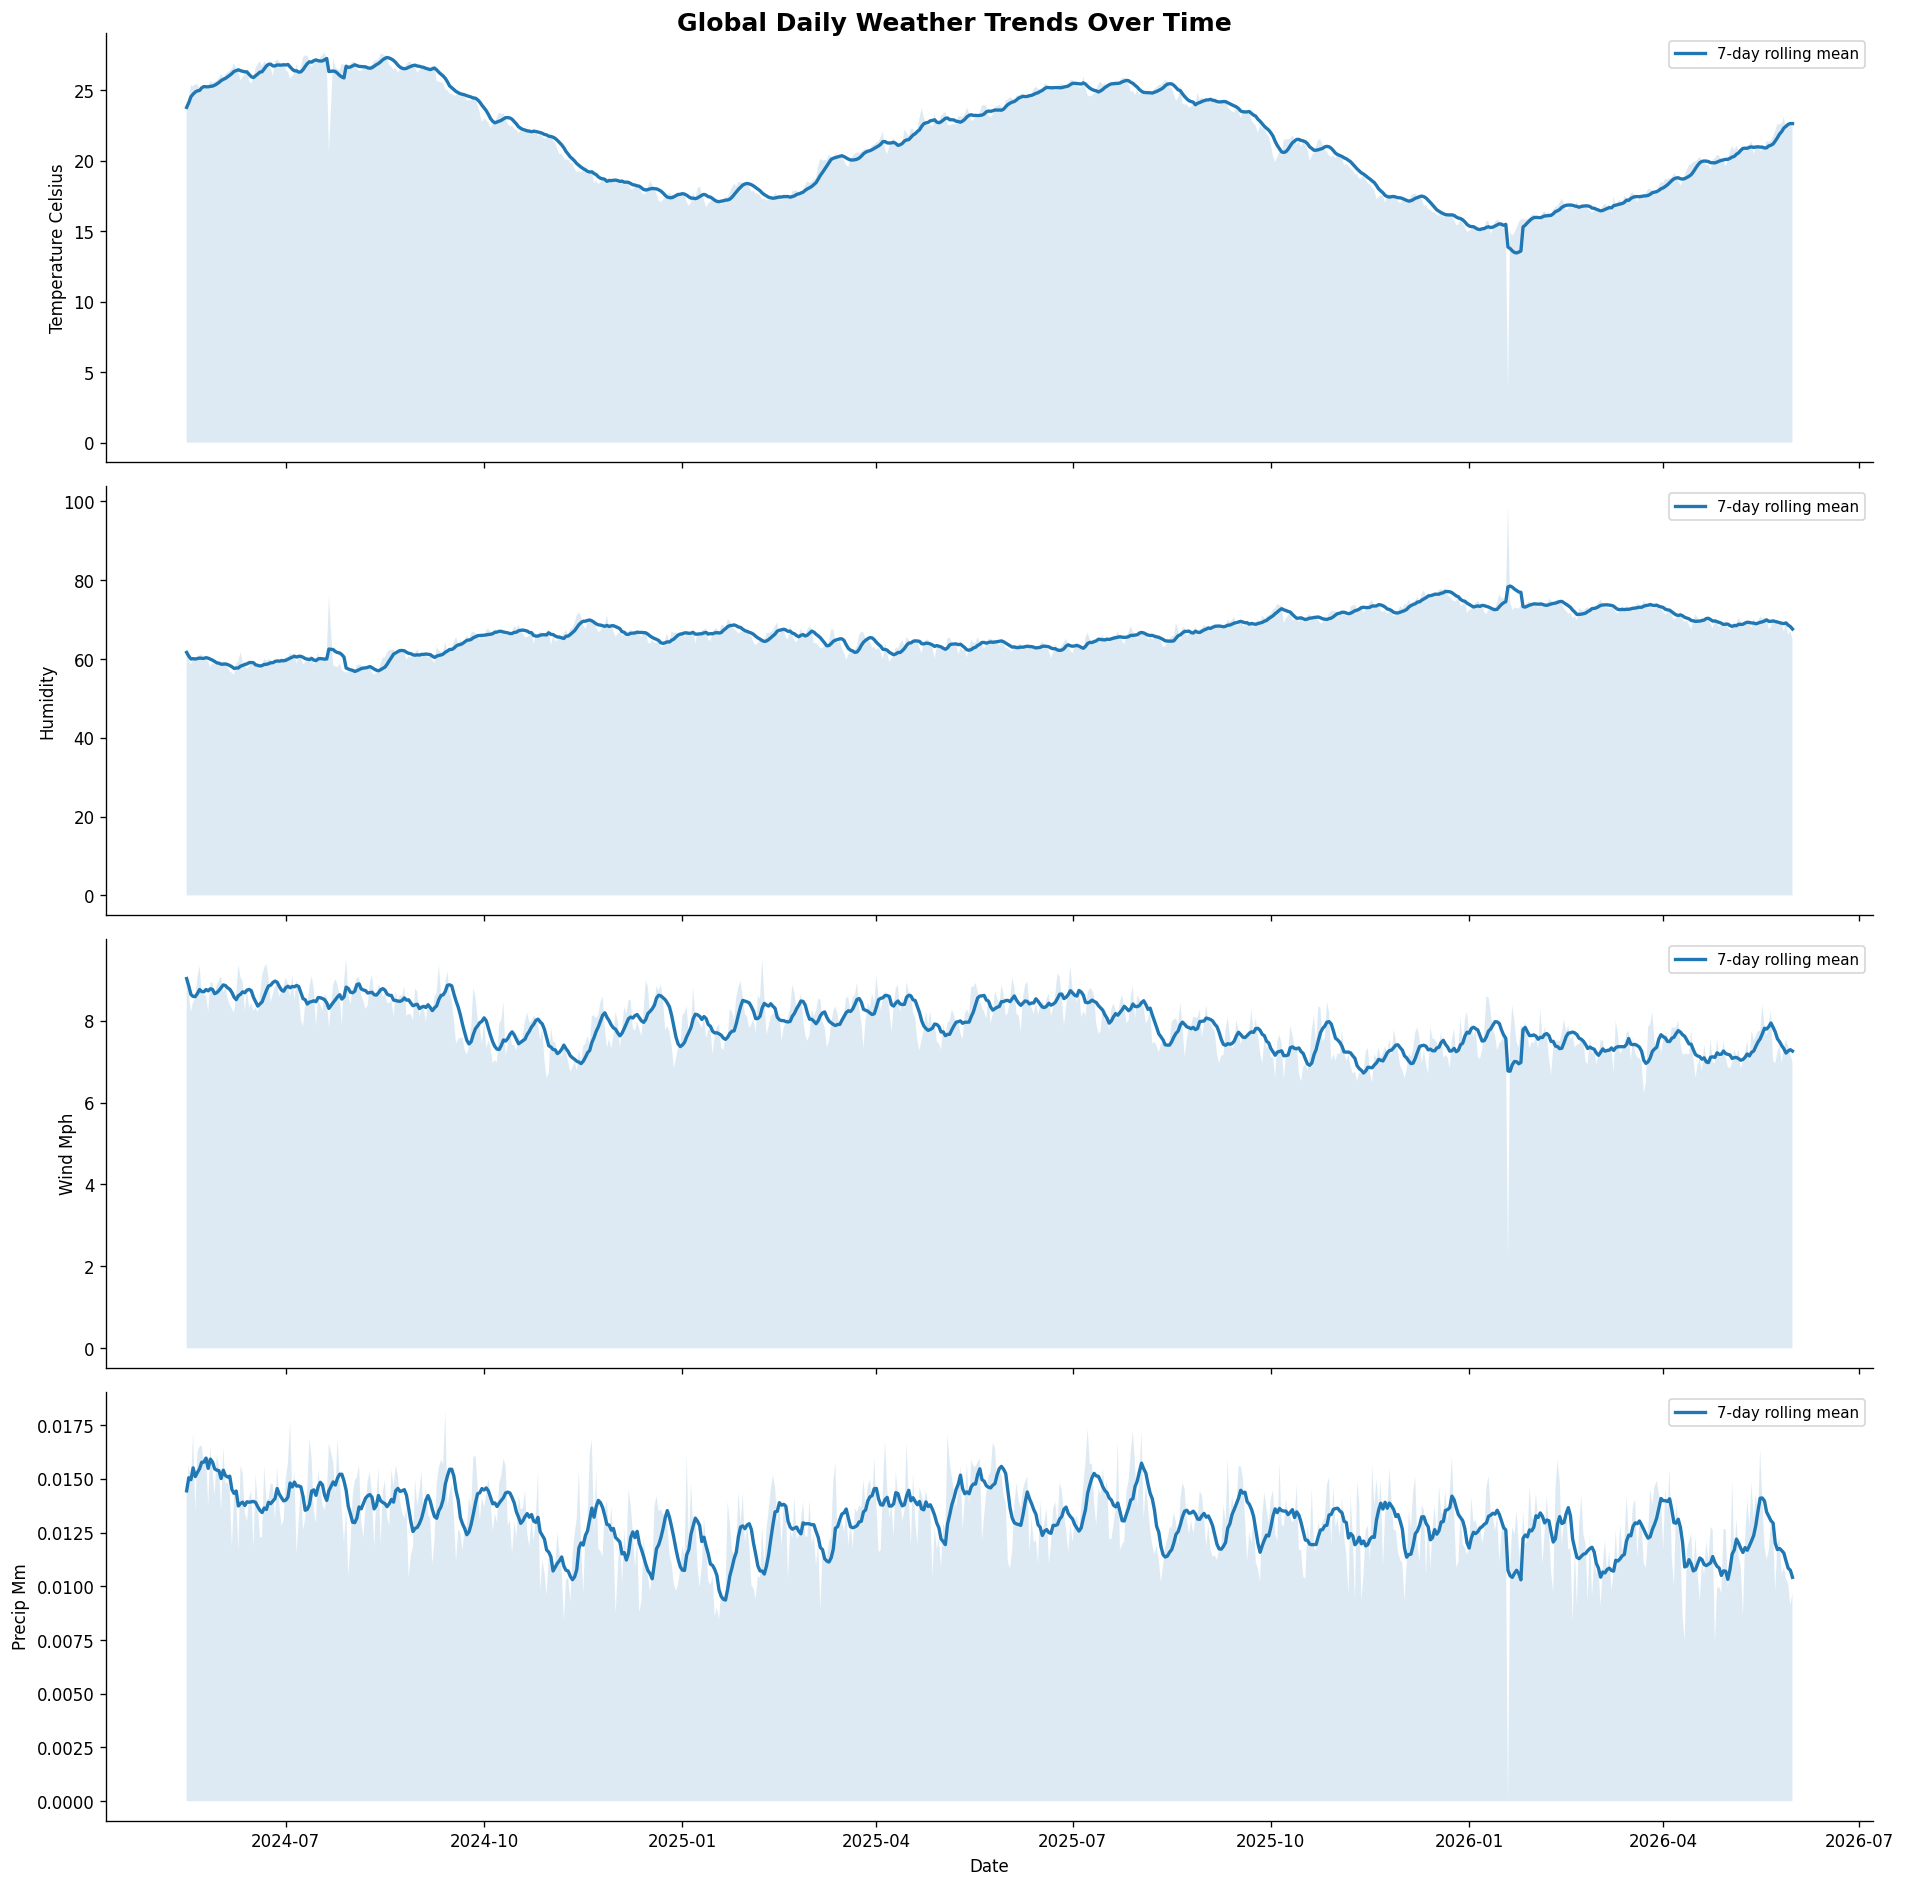

In [8]:
from src.explorer import plot_time_trends
Image(plot_time_trends(df))

## 3. Advanced EDA - Anomaly Detection

  Saved: outputs/figures/05_anomaly_detection.png

Anomaly summary:
  total_records: 144,627
  anomalies_iqr: 0
  anomalies_isolation_forest: 7,232
  anomalies_zscore_gt_3std: 0
  anomalies_consensus_at_least_2_methods: 0


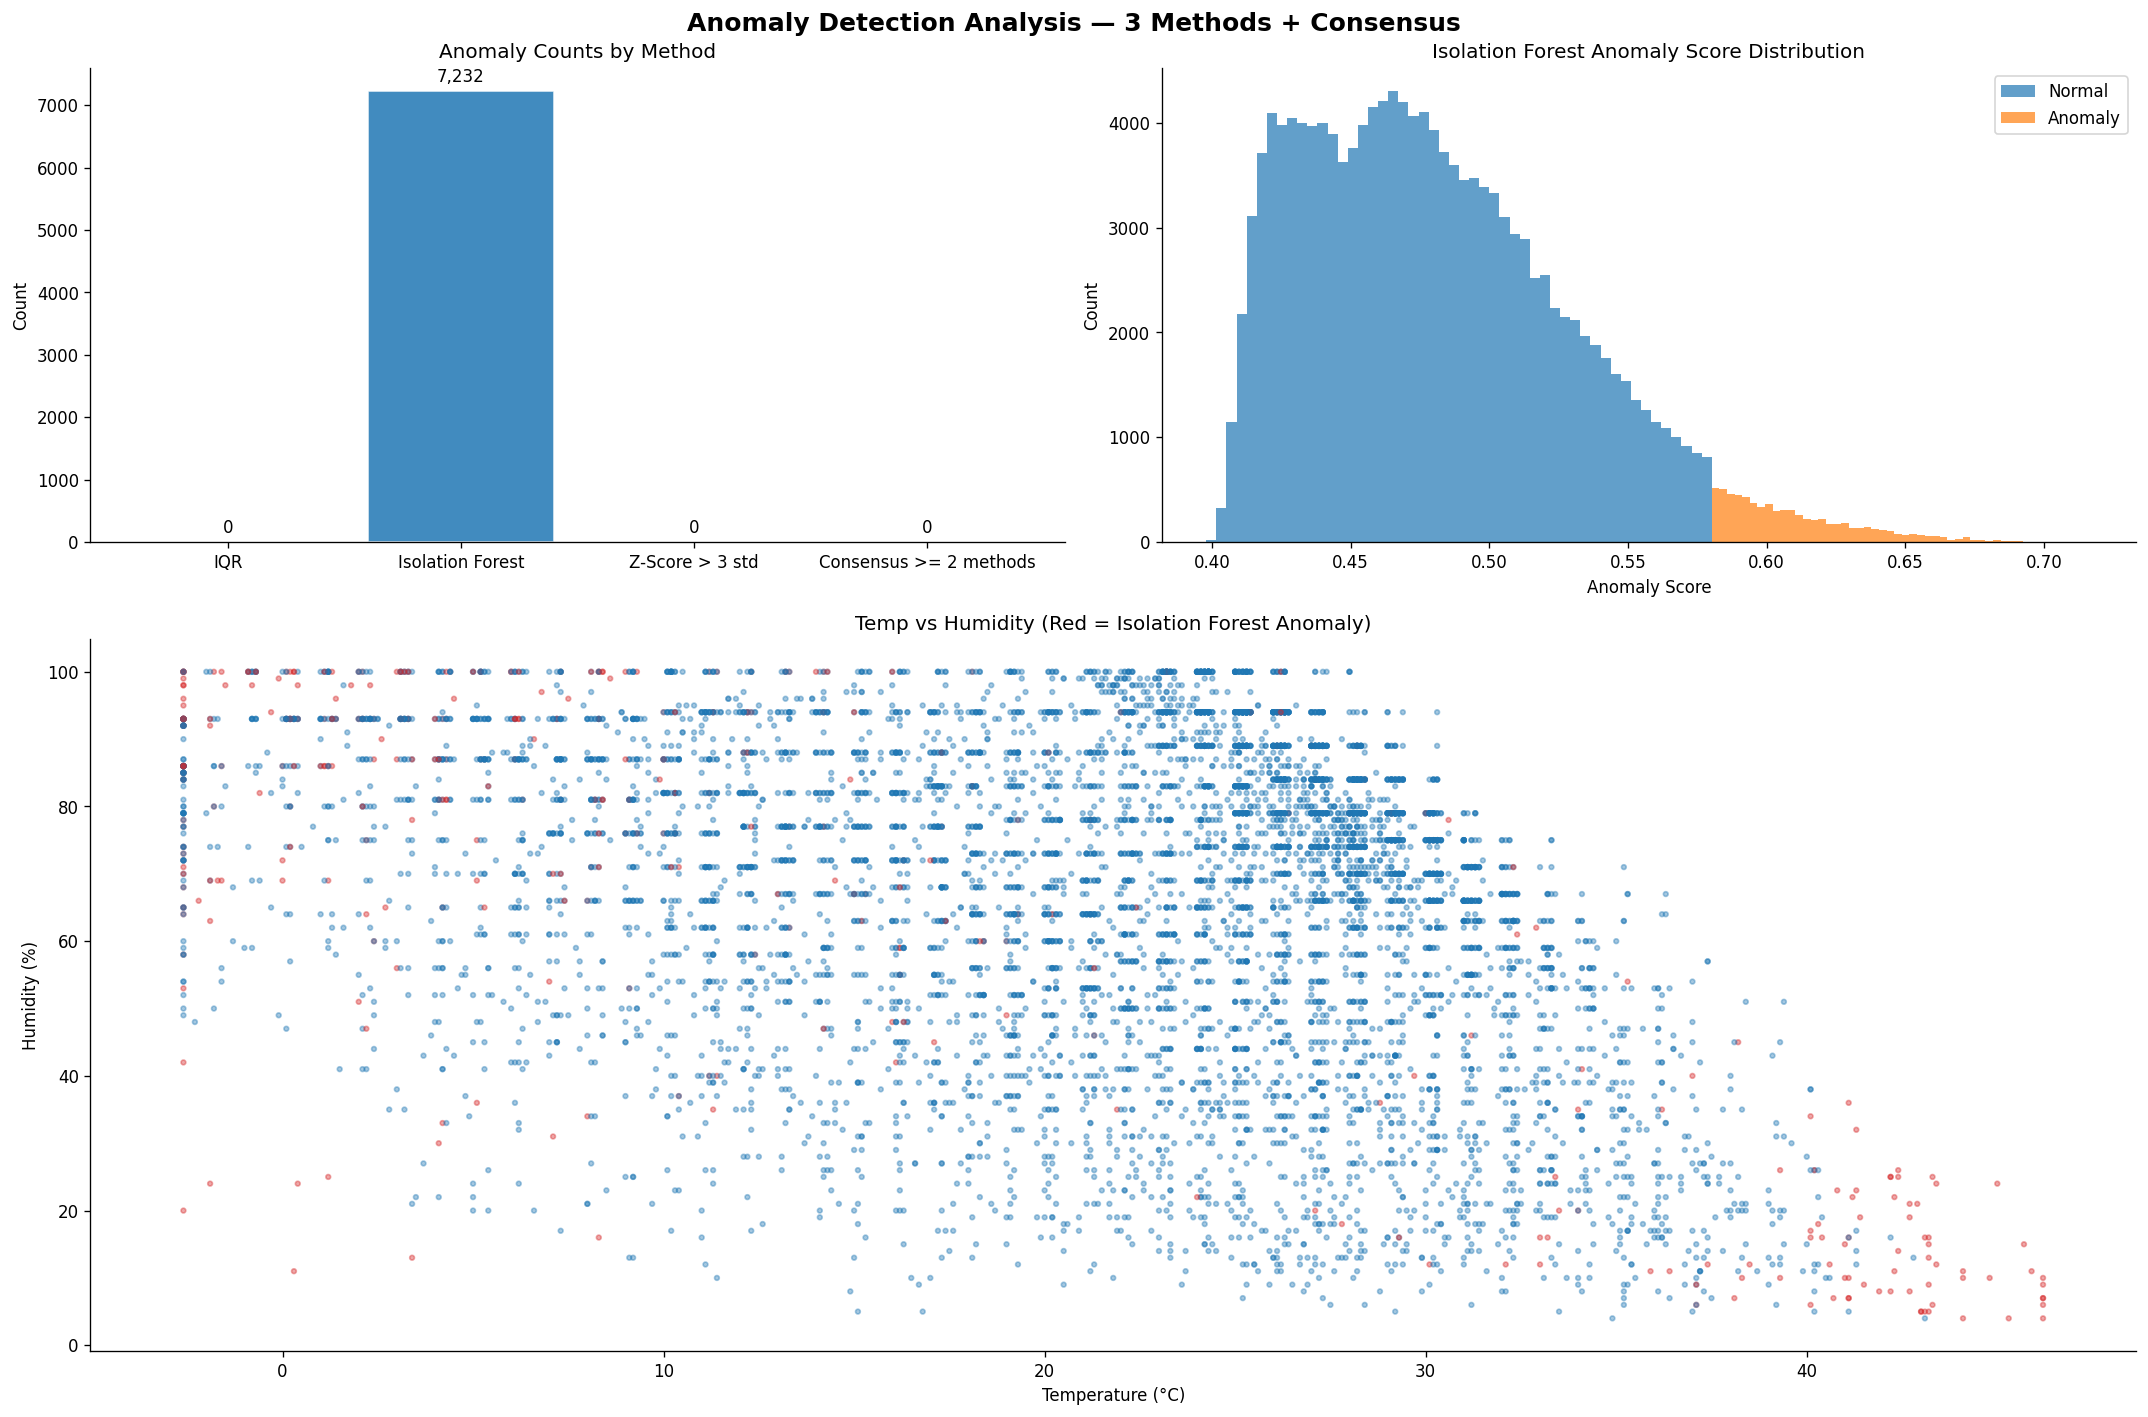

In [9]:
from src.explorer import detect_anomalies
df_flagged, fig_path, anomaly_summary = detect_anomalies(df, contamination=0.05)
print('\nAnomaly summary:')
for k, v in anomaly_summary.items():
    print(f'  {k}: {v:,}')
Image(fig_path)

Consensus anomalies: 0 (0.0%)
Records analyzed with anomaly_isoforest: 7,232 (5.0%)

Top-15 country anomaly-rate chart:
  Saved: outputs/figures/05_anomaly_detection_countries.png


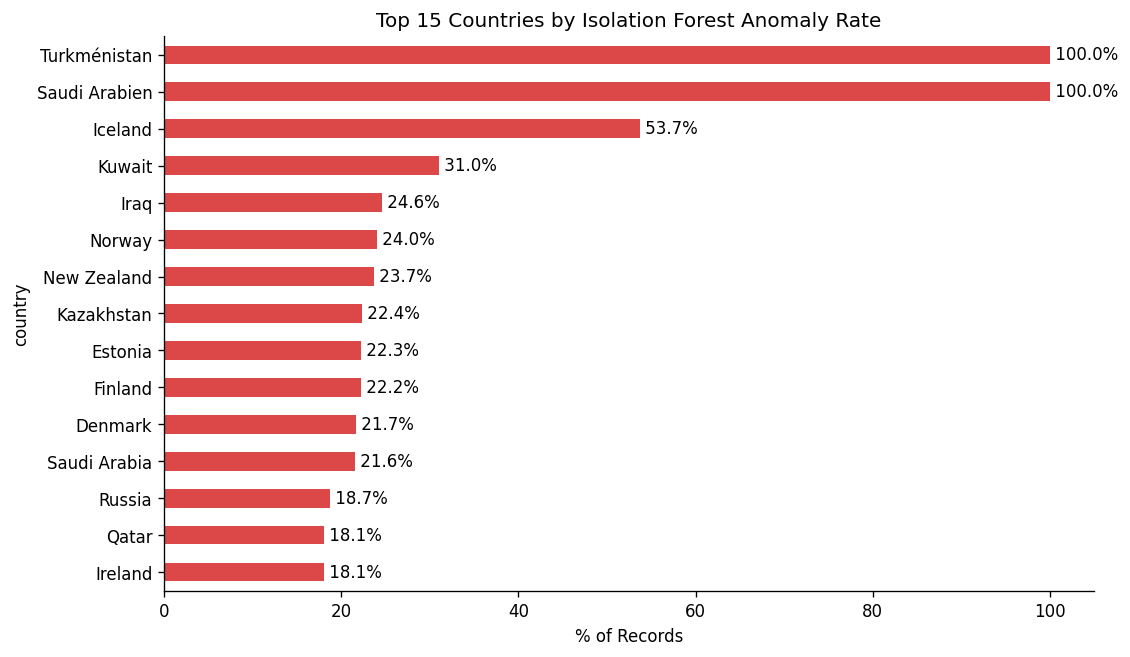


Top countries with anomalies:
country
Iceland         398
Kuwait          230
Iraq            183
Norway          178
New Zealand     176
Kazakhstan      166
Finland         165
Estonia         165
Denmark         161
Saudi Arabia    160


,temperature_celsius_normal,humidity_normal,wind_mph_normal,pressure_mb_normal,temperature_celsius_anomaly,humidity_anomaly,wind_mph_anomaly,pressure_mb_anomaly
mean,21.74,66.79,7.64,1014.34,13.88,66.73,12.92,1008.42
std,8.70,23.32,4.71,6.10,15.57,30.85,6.85,10.76
min,-2.60,2.00,2.20,998.00,-2.60,3.00,2.20,998.00
max,44.20,100.00,21.80,1030.00,46.20,100.00,21.80,1030.00


In [10]:
from IPython.display import Image, display

consensus_count = int(df_flagged['anomaly_consensus'].sum())
analysis_flag = 'anomaly_consensus' if consensus_count > 0 else 'anomaly_isoforest'
anom_df = df_flagged[df_flagged[analysis_flag] == 1]

print(f"Consensus anomalies: {consensus_count:,} ({consensus_count/len(df_flagged)*100:.1f}%)")
print(f"Records analyzed with {analysis_flag}: {len(anom_df):,} ({len(anom_df)/len(df_flagged)*100:.1f}%)")
print('\nTop-15 country anomaly-rate chart:')

# Display saved countries-only chart
from src.explorer import plot_anomaly_countries
countries_fig = plot_anomaly_countries(df_flagged, analysis_flag=analysis_flag, top_n=15)
if countries_fig:
    display(Image(countries_fig))
else:
    print('No country-level anomaly chart available.')

if 'country' in anom_df.columns and not anom_df.empty:
    print('\nTop countries with anomalies:')
    print(anom_df['country'].value_counts().head(10).to_string())
else:
    print('No anomaly records available for country-level inspection.')

key_cols2 = [c for c in ['temperature_celsius','humidity','wind_mph','pressure_mb'] if c in df.columns]
pd.concat([
    df_flagged[df_flagged[analysis_flag]==0][key_cols2].describe().round(2).add_suffix('_normal'),
    anom_df[key_cols2].describe().round(2).add_suffix('_anomaly')
], axis=1).loc[['mean','std','min','max']]

## 4. Forecasting Models

Models: SARIMA - Prophet - XGBoost - LightGBM - Random Forest - Ensemble

In [11]:
from src.forecasting import run_all_models
results, metrics_df, ts = run_all_models(df, target='temperature_celsius', steps=30)
print('\n Model Performance:')
metrics_df


Running forecasting models for: temperature_celsius
Time series: 746 D-periods | 2024-05-16 to 2026-05-31

[1/5] SARIMA...
[2/5] Prophet...


08:38:44 - cmdstanpy - INFO - Chain [1] start processing
08:38:44 - cmdstanpy - INFO - Chain [1] done processing


[3/5] XGBoost...
[4/5] LightGBM...
[5/5] Random Forest...

[Ensemble] Building weighted ensemble...

Model Performance:
                MAE   RMSE      R2   MAPE
model                                    
RandomForest  0.466  1.051  0.8231   4.16
XGBoost       0.473  1.065  0.8181   4.22
Ensemble      0.446  1.067  0.8176   4.08
LightGBM      0.461  1.083  0.8119   4.21
Prophet       1.124  1.565  0.6093   7.91
SARIMA        6.055  7.228 -7.3350  32.77

 Model Performance:


,MAE,RMSE,R2,MAPE
model,,,,
RandomForest,0.466,1.051,0.8231,4.16
XGBoost,0.473,1.065,0.8181,4.22
Ensemble,0.446,1.067,0.8176,4.08
LightGBM,0.461,1.083,0.8119,4.21
Prophet,1.124,1.565,0.6093,7.91
SARIMA,6.055,7.228,-7.3350,32.77


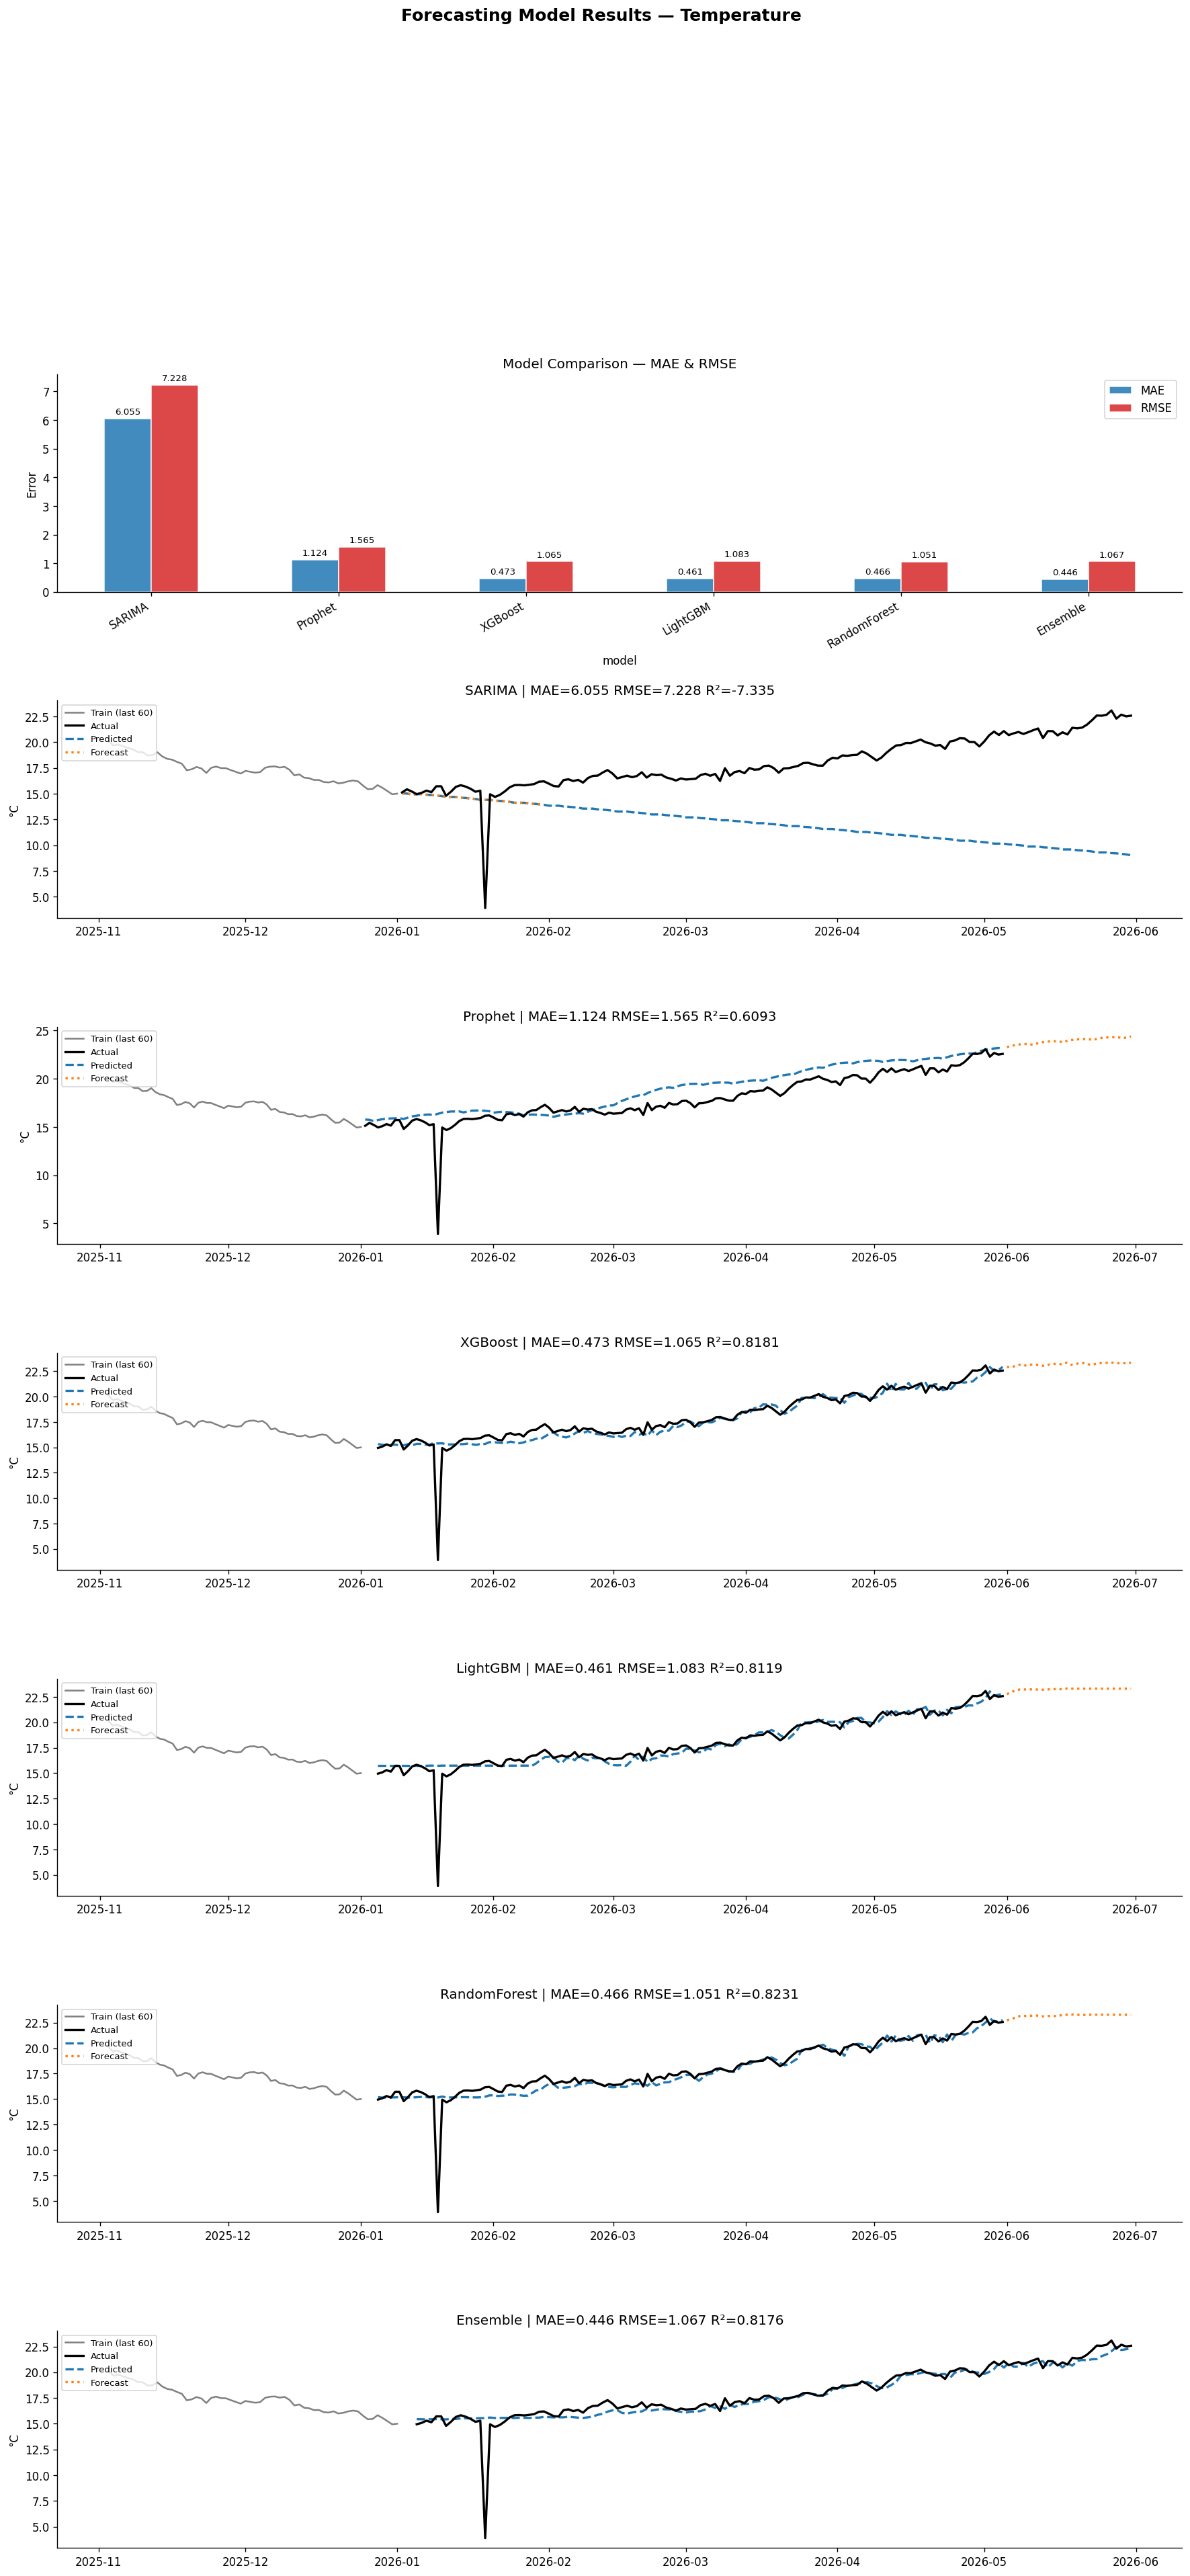

In [12]:
Image('outputs/figures/06_model_comparison.png')

In [13]:
if 'Ensemble' in results and results['Ensemble']:
    print('Ensemble weights (1/RMSE normalized):')
    weights = results['Ensemble']['weights']
    for model, w in sorted(weights.items(), key=lambda x: -x[1]):
        print(f'  {model:<15} {w:.4f}')
    print(f"\nEnsemble RMSE: {results['Ensemble']['metrics']['RMSE']}")
    print(f"Ensemble MAE:  {results['Ensemble']['metrics']['MAE']}")
    print(f"Ensemble R²:   {results['Ensemble']['metrics']['R2']}")

Ensemble weights (1/RMSE normalized):
  RandomForest    0.2650
  XGBoost         0.2615
  LightGBM        0.2571
  Prophet         0.1779
  SARIMA          0.0385

Ensemble RMSE: 1.067
Ensemble MAE:  0.446
Ensemble R²:   0.8176


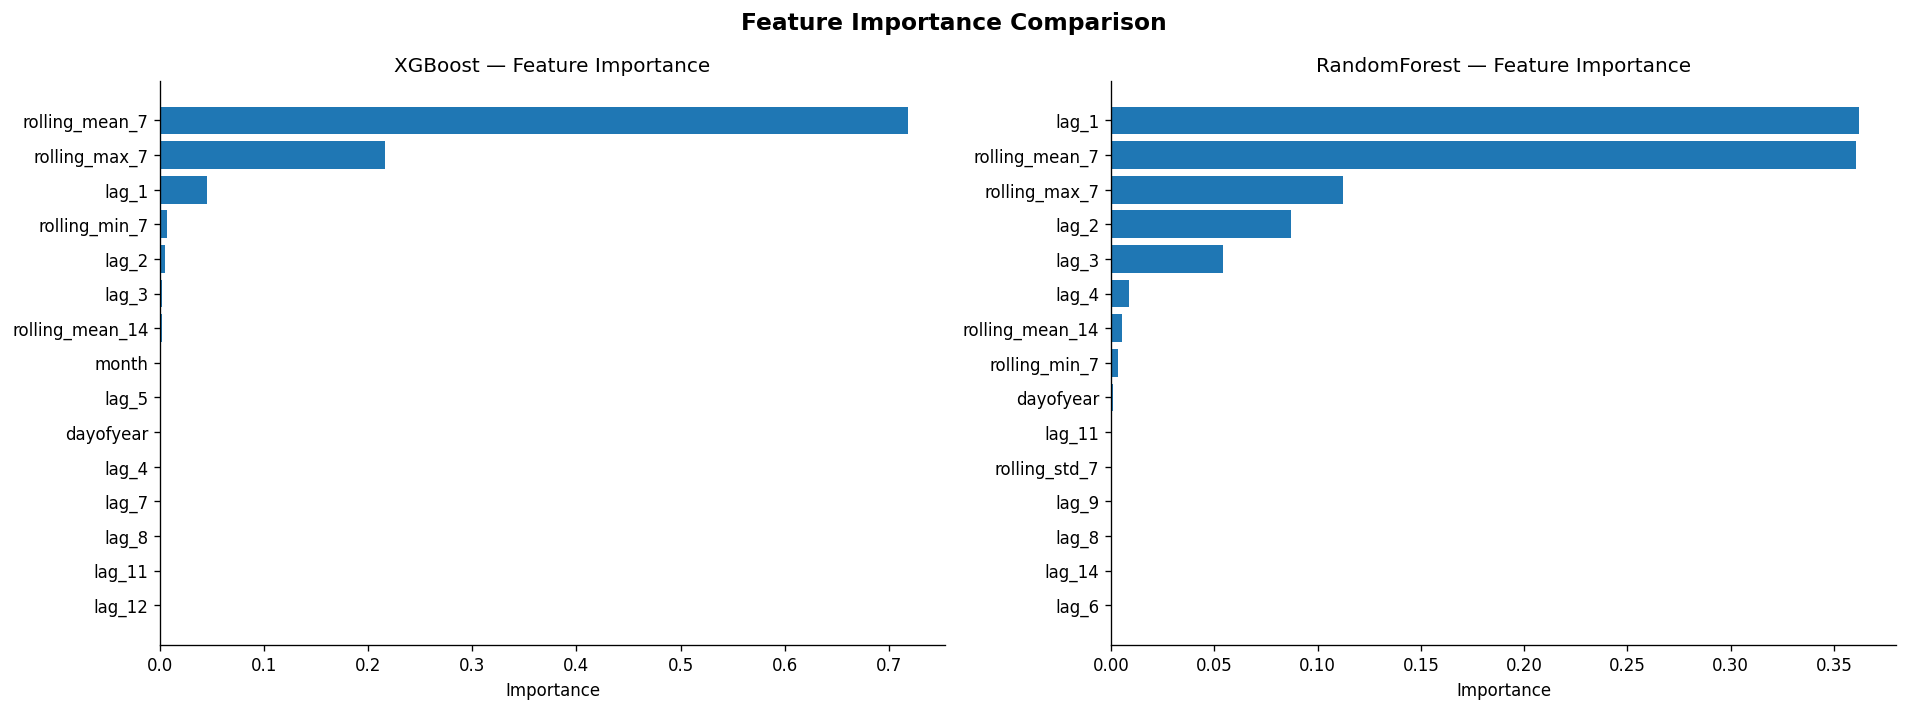

In [14]:
Image('outputs/figures/07_feature_importance.png')

## 5. Unique Analyses

  Saved: outputs/figures/08_climate_analysis.png


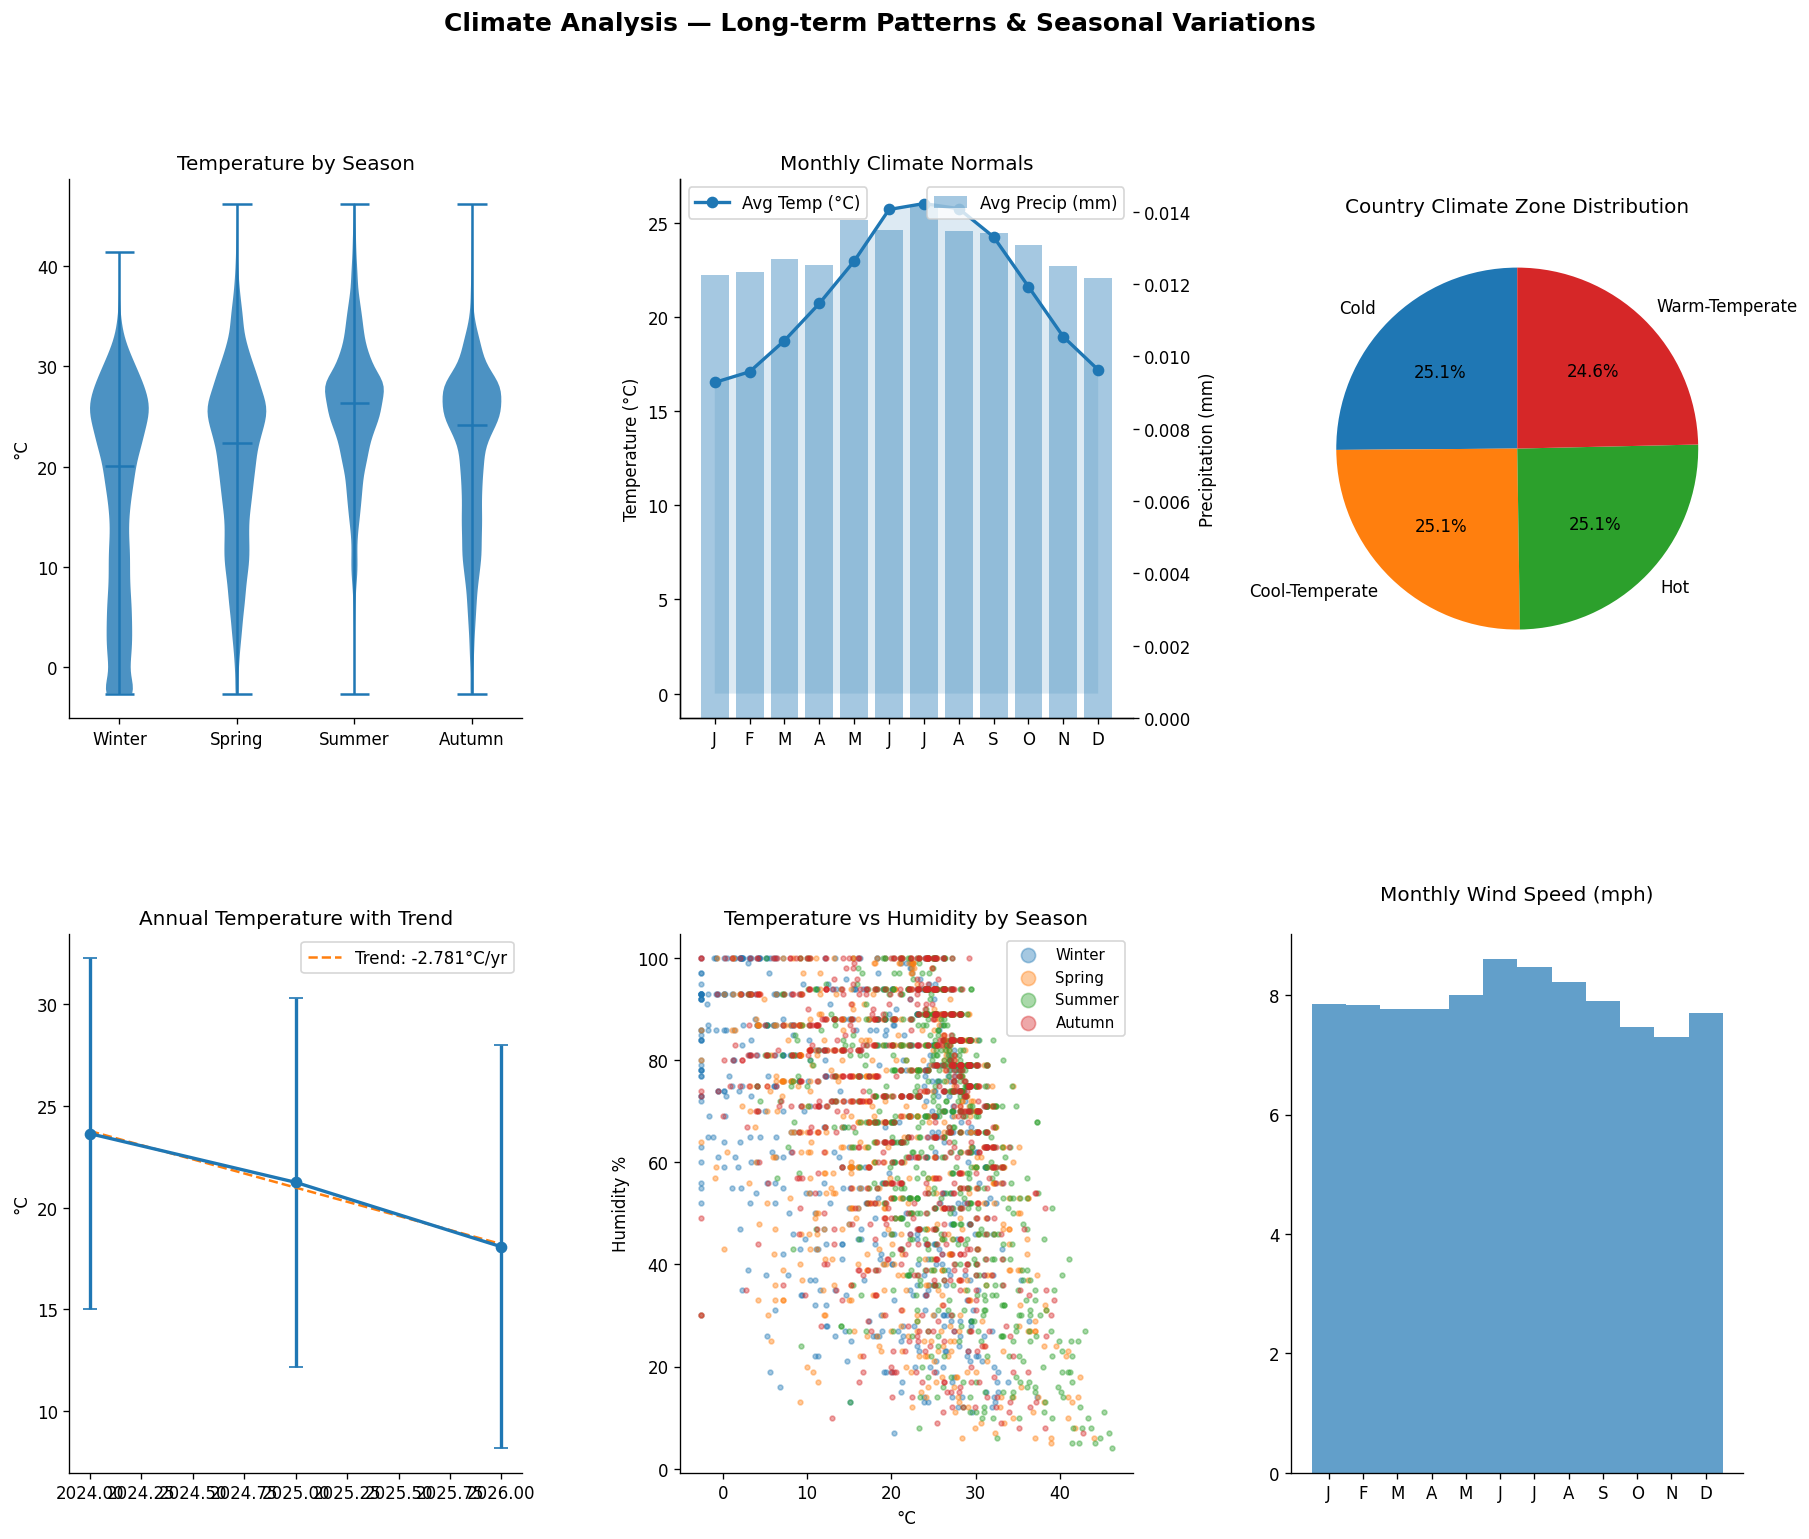

In [15]:
from src.unique_analyses import climate_analysis
Image(climate_analysis(df))

In [16]:
from src.unique_analyses import air_quality_analysis
result = air_quality_analysis(df)
if result: Image(result)

  Saved: outputs/figures/09_air_quality_analysis.png


  Saved: outputs/figures/10_feature_importance_analysis.png


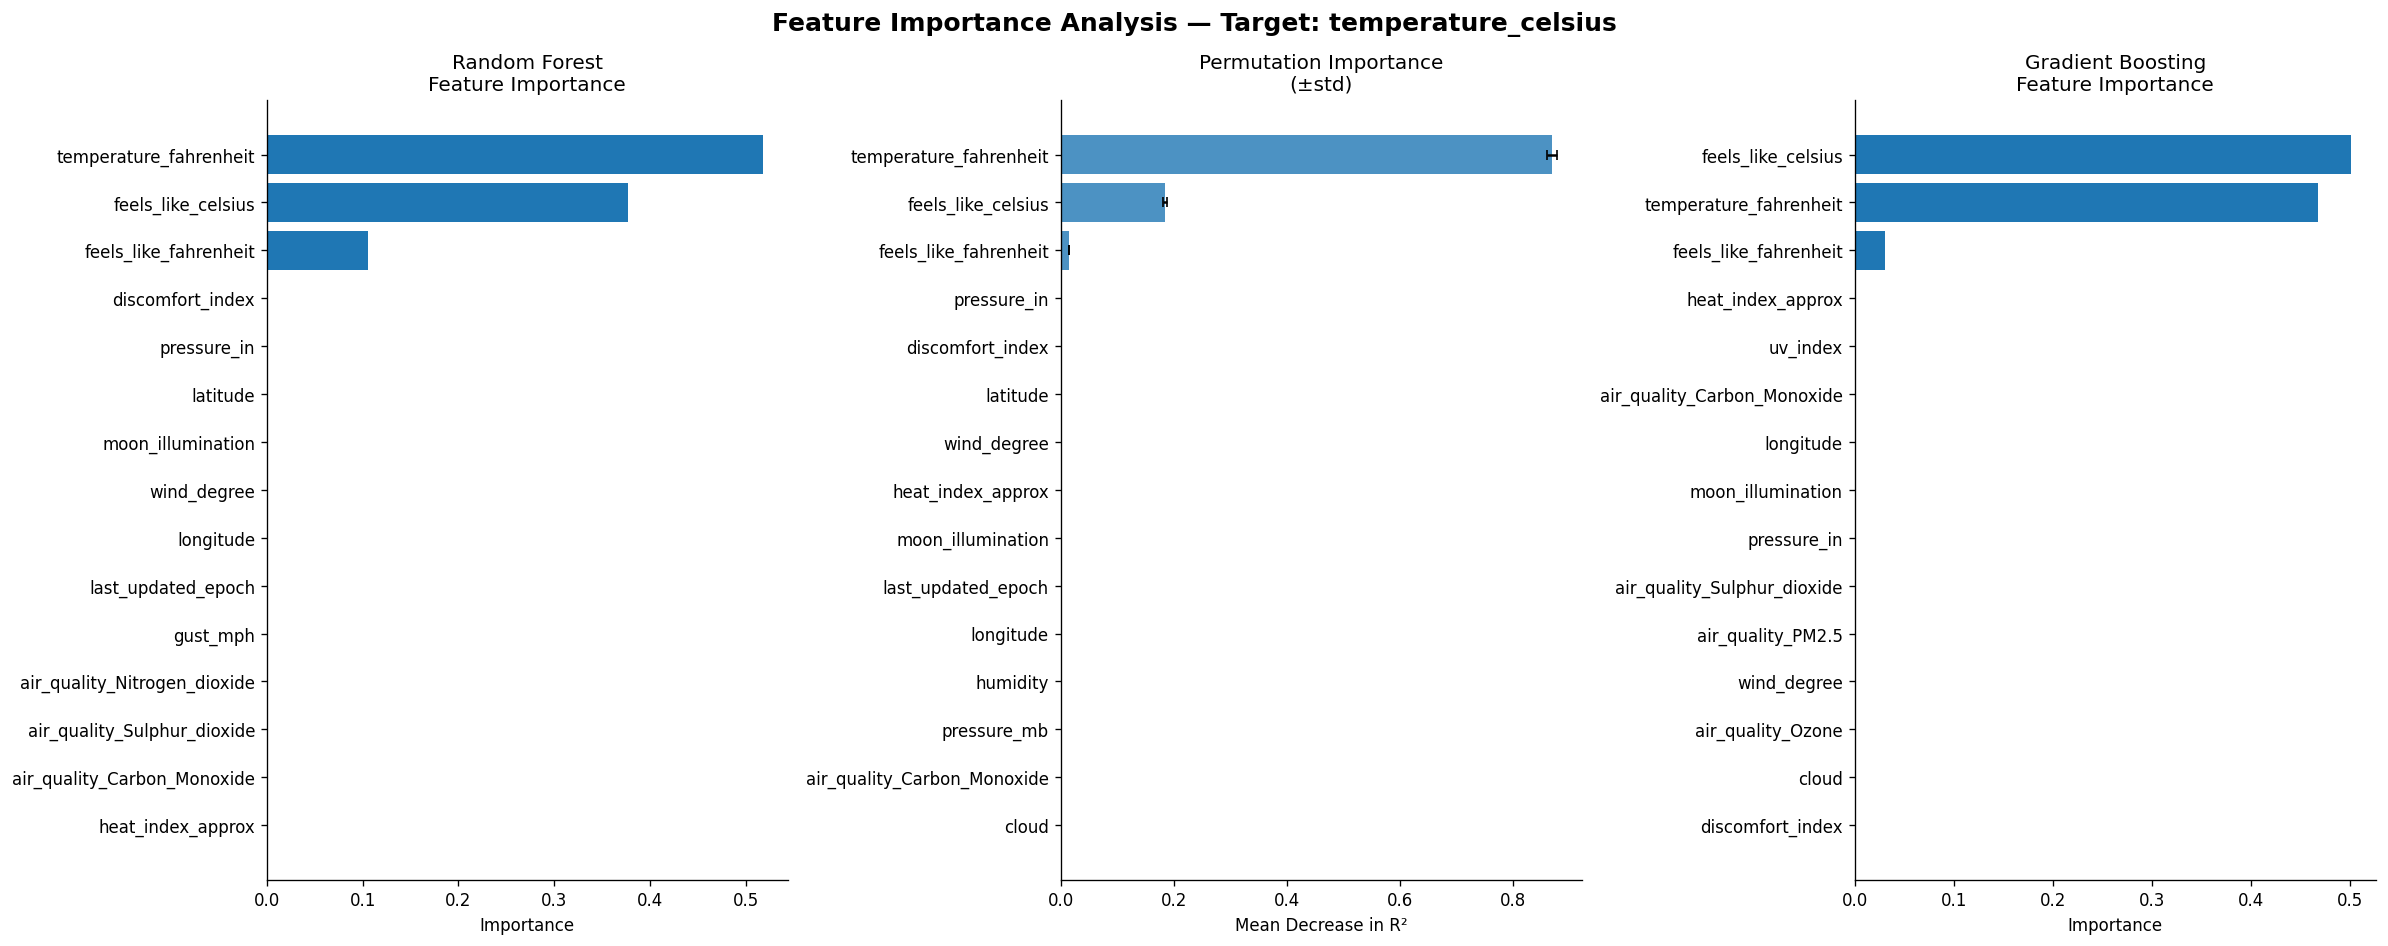

In [17]:
from src.unique_analyses import feature_importance_analysis
Image(feature_importance_analysis(df))

In [18]:
from src.unique_analyses import spatial_analysis
result = spatial_analysis(df)
if result: Image(result)

  Saved: outputs/figures/11_spatial_analysis.png


  Saved: outputs/figures/12_geographical_patterns.png


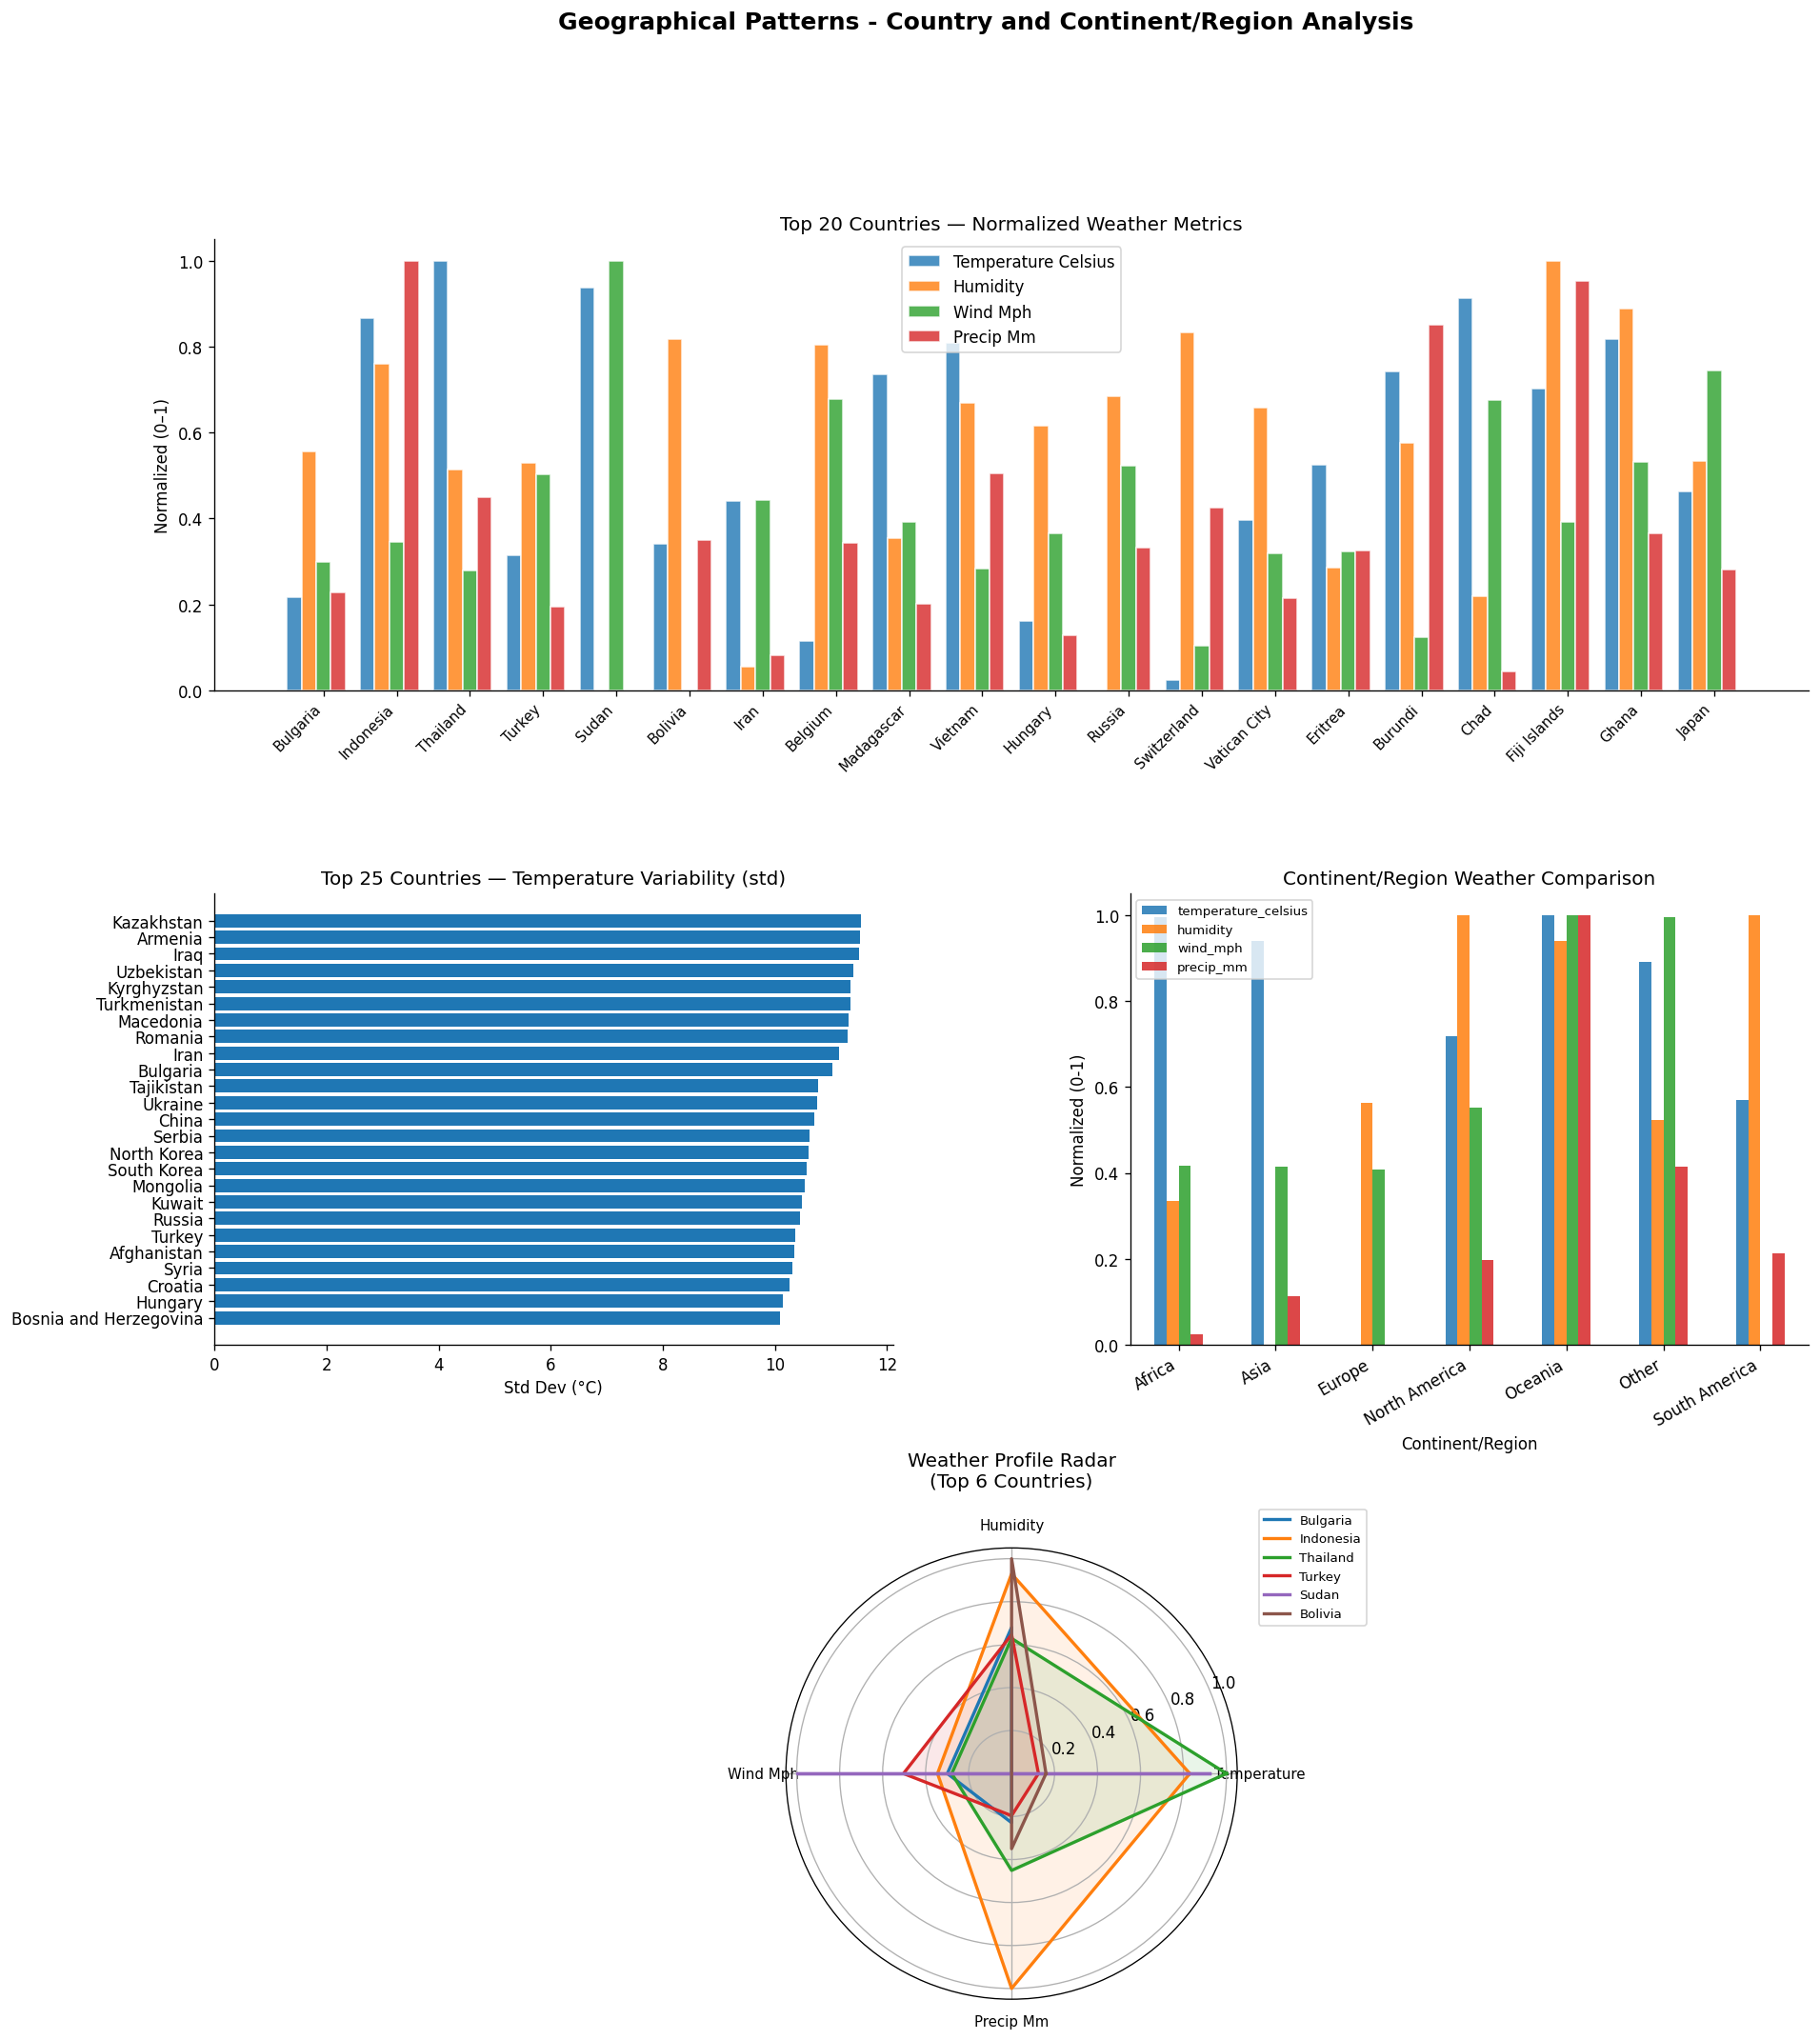

In [19]:
from src.unique_analyses import geographical_patterns
Image(geographical_patterns(df))

In [20]:
from main import run_pipeline

df_flagged, results, metrics_df = run_pipeline("data/GlobalWeatherRepository.csv")

Weather Trend Forecasting Pipeline

1. Cleaning and preprocessing
Loaded 144,627 rows x 41 columns

Missing values (0 columns affected):
Series([], )

After imputation: 0 total nulls remain

Outlier counts (before handling):
  temperature_celsius: 2,381
  wind_mph: 2,257
  humidity: 0
  pressure_mb: 4,183
  precip_mm: 29,242

Engineered features. Shape: (144627, 52)

Preprocessing complete. Final shape: (144627, 52)
Processed data saved: outputs\processed_globalweather.csv

2. Dataset overview
Rows/columns: (144627, 52)
Countries: 211
Cities: 257
Date range: ('2024-05-16 01:45:00', '2026-05-31 19:00:00')

3. Basic EDA
  Saved: outputs/figures/01_temperature_analysis.png
  Saved: outputs/figures/02_precipitation_analysis.png
  Saved: outputs/figures/03_correlation_heatmap.png
  Saved: outputs/figures/04_time_trends.png

4. Anomaly detection
  Saved: outputs/figures/05_anomaly_detection.png
Anomaly summary: {'total_records': 144627, 'anomalies_iqr': 0, 'anomalies_isolation_forest': 7232,

08:40:52 - cmdstanpy - INFO - Chain [1] start processing
08:40:52 - cmdstanpy - INFO - Chain [1] done processing


[2/5] Prophet...
[3/5] XGBoost...
[4/5] LightGBM...
[5/5] Random Forest...

[Ensemble] Building weighted ensemble...

Model Performance:
                MAE   RMSE      R2   MAPE
model                                    
RandomForest  0.466  1.051  0.8231   4.16
XGBoost       0.473  1.065  0.8181   4.22
Ensemble      0.446  1.067  0.8176   4.08
LightGBM      0.461  1.083  0.8119   4.21
Prophet       1.124  1.565  0.6093   7.91
SARIMA        6.055  7.228 -7.3350  32.77
Metrics saved: outputs\model_metrics.csv

Pipeline complete in 10.9 seconds.
Figures: outputs\figures
Models: outputs\models
